# TransitionRx — RAG Component

**Decision Analytics | Retrieval-Augmented Guidance for Discharge Decision Support**

This notebook is the RAG half of TransitionRx. It is **not** a general chatbot: it answers a
narrow set of questions tied to one decision —

> *Which discharged diabetes patients should get limited pharmacist / case-manager follow-up, and once flagged, what should staff actually do?*

The XGBoost model says **who** is high risk. This component says **what to do about it**, grounded
in CMS and AHRQ guidance rather than model-invented advice.

### Required elements → where they live

| Requirement | Section |
|---|---|
| Document collection | 2 |
| Document loading & preprocessing | 3 |
| Chunking strategy | 4 |
| Embeddings | 5 |
| Vector search / retrieval | 6 |
| Prompt design | 7 |
| Generated response | 8 |
| Source grounding / citation | 8–9 |
| Evaluation, limitations, failure modes | 10–12 |

### Two stakeholder-facing functions
1. **Guidance Q&A** — "What does AHRQ recommend for discharge medication reconciliation?"
2. **Patient Action Brief** — takes a flagged patient's SHAP drivers and returns cited, recommended follow-up actions. *This is the piece that connects model output to action.*

## 1. Setup

In [1]:
!pip install -q sentence-transformers faiss-cpu pypdf python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.9/382.9 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 12.7 MB/s eta 0:00:00


In [2]:
import os, re, json, glob, hashlib, textwrap
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

# ---- POINT THIS AT YOUR DRIVE FOLDER ----
CORPUS_DIR = "/content/drive/MyDrive/TransitionRx_Corpus"
# -----------------------------------------

os.makedirs(CORPUS_DIR, exist_ok=True)
print("Corpus folder:", CORPUS_DIR)
print("Files found:", len(glob.glob(os.path.join(CORPUS_DIR, "**", "*"), recursive=True)))

Mounted at /content/drive
Corpus folder: /content/drive/MyDrive/TransitionRx_Corpus
Files found: 6


## 2. Document collection

Drop PDFs / DOCX / TXT / MD into the Drive folder above. Everything here is public,
authoritative, and on-topic — that curation *is* the grounding strategy.

| Document | Why it's in the corpus |
|---|---|
| AHRQ **RED** Toolkit (Re-Engineered Discharge) | The discharge bundle: med rec, teach-back education, follow-up call |
| AHRQ **MATCH** Toolkit | Medication reconciliation specifics + high-risk situations |
| **42 CFR § 482.43** — CMS Discharge Planning CoP | The regulatory obligation to reduce preventable readmissions |
| AHRQ **Health Literacy Universal Precautions** Toolkit | The patient-education half of the thesis |
| CMS **Hospital Discharge Planning Worksheet** | What surveyors actually check |
| CMS **HRRP** program materials | The financial stakes behind the decision |

> **Scope rule:** only readmission, discharge-planning, care-transition, and healthcare-quality
> documents. Anything outside that scope makes the retriever worse, not better — an off-topic
> document can only ever be a false positive.

In [3]:
# Inventory whatever is actually in the folder
SUPPORTED = (".pdf", ".txt", ".md", ".docx")
paths = [p for p in glob.glob(os.path.join(CORPUS_DIR, "**", "*"), recursive=True)
         if p.lower().endswith(SUPPORTED)]

if not paths:
    raise SystemExit(f"No documents found in {CORPUS_DIR}. Upload your corpus and re-run.")

inv = pd.DataFrame({
    "file": [os.path.basename(p) for p in paths],
    "type": [os.path.splitext(p)[1].lower() for p in paths],
    "size_kb": [round(os.path.getsize(p) / 1024, 1) for p in paths],
}).sort_values("file")

print(f"{len(paths)} documents\n")
display(inv)

6 documents



,file,type,size_kb
5,2026_CBM_FAQ.pdf,.pdf,1586.7
2,42 CFR 482.43 (up to date as of 8-20-2026).pdf,.pdf,46.9
4,July2026-Readmission-HUG.pdf,.pdf,596.3
3,health-literacy-toolkit-third-edition.pdf,.pdf,2116.1
0,match.pdf,.pdf,1668.8
1,redtoolkit.pdf,.pdf,2324.5


## 3. Document loading & preprocessing

PDFs of government toolkits are messy: headers/footers on every page, hyphenated line breaks,
page numbers mid-sentence. Cleaning matters more than model choice here — dirty chunks retrieve badly.

Page numbers are preserved for PDFs so citations can point to a page.

In [4]:
from pypdf import PdfReader
import docx as docxlib

def read_pdf(path):
    """Return list of (page_number, text)."""
    out = []
    try:
        reader = PdfReader(path)
        for i, page in enumerate(reader.pages, 1):
            t = page.extract_text() or ""
            if t.strip():
                out.append((i, t))
    except Exception as e:
        print(f"  ! failed {os.path.basename(path)}: {e}")
    return out

def read_docx(path):
    d = docxlib.Document(path)
    parts = [p.text for p in d.paragraphs if p.text.strip()]
    for tbl in d.tables:
        for row in tbl.rows:
            cells = [cl.text.strip() for cl in row.cells if cl.text.strip()]
            if cells:
                parts.append(" | ".join(cells))
    return [(None, "\n".join(parts))]

def read_plain(path):
    with open(path, encoding="utf-8", errors="ignore") as f:
        return [(None, f.read())]

def clean_text(t):
    t = t.replace("\r\n", "\n")
    t = re.sub(r"-\n(?=[a-z])", "", t)          # de-hyphenate across line breaks
    t = re.sub(r"\n(?=[a-z,;)])", " ", t)       # unwrap mid-sentence breaks
    t = re.sub(r"\n\s*\d{1,3}\s*\n", "\n", t) # bare page numbers
    t = re.sub(r"[ \t]{2,}", " ", t)
    t = re.sub(r"\n{3,}", "\n\n", t)
    return t.strip()

records = []
for p in sorted(paths):
    ext = os.path.splitext(p)[1].lower()
    pages = (read_pdf(p) if ext == ".pdf" else
             read_docx(p) if ext == ".docx" else read_plain(p))
    for page_no, raw in pages:
        cleaned = clean_text(raw)
        if len(cleaned) > 200:          # skip near-empty pages
            records.append({"source": os.path.basename(p),
                            "page": page_no, "text": cleaned})

print(f"Loaded {len(records)} page/document units from {len(paths)} files")
print(f"Total characters: {sum(len(r['text']) for r in records):,}")

Loaded 476 page/document units from 6 files
Total characters: 891,800


## 4. Chunking strategy

**Paragraph-aware, ~900 characters, ~150 character overlap.**

Rationale:
- **Paragraph-aware** — guidance documents are written as self-contained recommendations. Splitting mid-recommendation produces chunks that retrieve but don't *answer*.
- **~900 chars (~200 tokens)** — big enough to hold a complete recommendation, small enough that a retrieved chunk is mostly signal. Toolkit recommendations are short.
- **150-char overlap** — protects against a recommendation straddling a boundary.
- **Metadata on every chunk** — source file and page, so every retrieved passage can be cited.

In [5]:
CHUNK_SIZE, CHUNK_OVERLAP = 900, 150

def chunk_text(text, size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    paras = [p.strip() for p in text.split("\n\n") if p.strip()]
    chunks, cur = [], ""
    for p in paras:
        if len(cur) + len(p) + 2 <= size:
            cur = (cur + "\n\n" + p).strip()
        else:
            if cur:
                chunks.append(cur)
            if len(p) <= size:
                cur = p
            else:                                  # hard-split oversized paragraph
                for i in range(0, len(p), size - overlap):
                    chunks.append(p[i:i + size])
                cur = ""
    if cur:
        chunks.append(cur)

    stitched = []
    for i, ch in enumerate(chunks):
        if i > 0 and overlap > 0:
            stitched.append(chunks[i - 1][-overlap:] + " " + ch)
        else:
            stitched.append(ch)
    return stitched

CHUNKS = []
for r in records:
    for j, ch in enumerate(chunk_text(r["text"])):
        CHUNKS.append({
            "chunk_id": hashlib.md5(f"{r['source']}-{r['page']}-{j}".encode()).hexdigest()[:10],
            "source": r["source"],
            "page": r["page"],
            "chunk_index": j,
            "text": ch,
        })

chunk_df = pd.DataFrame(CHUNKS)
print(f"{len(CHUNKS)} chunks | mean {chunk_df['text'].str.len().mean():.0f} chars")
display(chunk_df.groupby("source").agg(chunks=("chunk_id", "count"),
                                       mean_chars=("text", lambda s: int(s.str.len().mean()))))

1408 chunks | mean 829 chars


,chunks,mean_chars
source,,
2026_CBM_FAQ.pdf,124,815
42 CFR 482.43 (up to date as of 8-20-2026).pdf,12,896
July2026-Readmission-HUG.pdf,154,881
health-literacy-toolkit-third-edition.pdf,449,772
match.pdf,287,827
redtoolkit.pdf,382,876


## 5. Embeddings

`all-MiniLM-L6-v2` — 384-dim sentence embeddings, runs free on Colab CPU in seconds, no API key.

Why not OpenAI embeddings: this corpus is small (hundreds of chunks), the domain vocabulary is
ordinary clinical English, and a local model keeps the whole component reproducible for grading
without anyone needing a paid key. Vectors are L2-normalized so inner product = cosine similarity.

In [6]:
from sentence_transformers import SentenceTransformer

EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBED_MODEL)

def embed(texts):
    v = embedder.encode(list(texts), batch_size=64, show_progress_bar=False,
                        convert_to_numpy=True, normalize_embeddings=True)
    return v.astype("float32")

EMB = embed([c["text"] for c in CHUNKS])
print("Embedding matrix:", EMB.shape)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding matrix: (1408, 384)


## 6. Vector search / retrieval

FAISS `IndexFlatIP` — exact search. At this corpus size an approximate index would trade
accuracy for speed we don't need.

Retrieval adds two things beyond plain top-k:
- **A similarity floor.** If nothing clears it, the system says *"not covered by the corpus"* instead of returning the least-bad chunk. This is the main defense against confident nonsense.
- **Per-source capping.** Prevents one verbose document from crowding out the rest.

In [7]:
import faiss

index = faiss.IndexFlatIP(EMB.shape[1])
index.add(EMB)
print(f"Indexed {index.ntotal} chunks")

MIN_SIMILARITY = 0.25          # tuned in Section 10
MAX_PER_SOURCE = 2

def retrieve(query, k=4, min_sim=MIN_SIMILARITY, max_per_source=MAX_PER_SOURCE):
    qv = embed([query])
    scores, idxs = index.search(qv, k * 4)
    hits, per_source = [], {}
    for i, s in zip(idxs[0], scores[0]):
        if i < 0 or s < min_sim:
            continue
        src = CHUNKS[i]["source"]
        if per_source.get(src, 0) >= max_per_source:
            continue
        per_source[src] = per_source.get(src, 0) + 1
        hits.append({**CHUNKS[i], "score": float(s)})
        if len(hits) == k:
            break
    return hits

for h in retrieve("what should happen during medication reconciliation at discharge"):
    print(f"{h['score']:.3f}  {h['source']} p.{h['page']}")
    print(textwrap.fill(h["text"][:200], 100, initial_indent="      ",
                        subsequent_indent="      "), "...\n")

Indexed 1408 chunks
0.788  redtoolkit.pdf p.41
      (2) arrange for the patient to obtain the medicine. The purpose of medicine reconciliation in
      preparation for hospital discharge is to determine that  (2) arrange for the patient to obtain
      the medicin ...

0.745  redtoolkit.pdf p.73
      Re-Engineered Discharge (RED) Toolkit: Tool 5 65  ■ Home services and equipment. You will
      confirm that home services and equipment have been delivered as expected and discuss the need
      for additional h ...

0.718  match.pdf p.33
      27 Designing the Process—Considerations for Various  Practice Settings  Finding a starting
      point for improving the medication reconciliation project should be driven by understanding
      the needs of vari ...

0.718  match.pdf p.35
      arge medication list, educate patient, etc.). The goal for discharge medication reconciliation
      includes:  ■ Comparing the patient’s pre-admission medi arge medication list, educate patient,
      et

## 7. Prompt design

Two prompts, both built on the same rules:

1. **Answer only from the excerpts.** No outside clinical knowledge.
2. **Cite `[n]` inline** on every factual claim.
3. **Say so when the corpus doesn't cover it** rather than guessing.
4. **Address the stakeholder** — a pharmacist or case manager acting at discharge, not a general reader.
5. **Never give patient-specific clinical orders.** The tool routes attention and cites policy; a
   clinician decides. This boundary is deliberate — an LLM reading billing data must not be
   the thing that decides someone's insulin dose.

In [8]:
SYSTEM_PROMPT = """You are a discharge-planning guidance assistant for a hospital pharmacy and \
care-management team. You support the TransitionRx project, which flags diabetes patients at \
elevated risk of 30-day readmission so limited pharmacist time can be targeted.

Rules:
1. Answer ONLY from the numbered excerpts provided. Do not add outside clinical knowledge.
2. Cite the excerpt number [1], [2] inline after each claim it supports.
3. If the excerpts do not cover the question, say so plainly. Do not speculate.
4. Write for a busy pharmacist or case manager: concrete, actionable, brief.
5. Recommend PROCESS steps (reconciliation, education, follow-up scheduling). Never recommend \
specific drugs, doses, or clinical treatment decisions for an individual patient.
6. If excerpts conflict, surface the disagreement rather than picking one."""


def build_context(hits):
    blocks = []
    for n, h in enumerate(hits, 1):
        loc = f", p.{h['page']}" if h["page"] else ""
        blocks.append(f"[{n}] SOURCE: {h['source']}{loc}\n{h['text']}")
    return "\n\n---\n\n".join(blocks)


def guidance_prompt(question, hits):
    return f"""{SYSTEM_PROMPT}

EXCERPTS:
{build_context(hits)}

QUESTION: {question}

Answer with inline [n] citations. If the excerpts don't cover it, say so."""


def patient_brief_prompt(risk_score, threshold, drivers, hits):
    driver_lines = "\n".join(
        f"- {d['feature']} = {d['value']} ({d['direction']} risk)" for d in drivers)
    return f"""{SYSTEM_PROMPT}

FLAGGED PATIENT (de-identified model output):
Readmission risk score: {risk_score:.2f} (flag threshold {threshold:.2f})
Top model drivers:
{driver_lines}

EXCERPTS:
{build_context(hits)}

TASK: Write a short action brief for the pharmacist:
1. One sentence on why this patient was flagged, in plain language.
2. 3-5 recommended PROCESS actions before/after discharge, each with a [n] citation.
3. Note anything the model cannot see that the pharmacist should check.
Do not recommend specific drugs or doses."""

print(guidance_prompt("What is required for discharge medication reconciliation?",
                      retrieve("discharge medication reconciliation requirement"))[:1200])

You are a discharge-planning guidance assistant for a hospital pharmacy and care-management team. You support the TransitionRx project, which flags diabetes patients at elevated risk of 30-day readmission so limited pharmacist time can be targeted.

Rules:
1. Answer ONLY from the numbered excerpts provided. Do not add outside clinical knowledge.
2. Cite the excerpt number [1], [2] inline after each claim it supports.
3. If the excerpts do not cover the question, say so plainly. Do not speculate.
4. Write for a busy pharmacist or case manager: concrete, actionable, brief.
5. Recommend PROCESS steps (reconciliation, education, follow-up scheduling). Never recommend specific drugs, doses, or clinical treatment decisions for an individual patient.
6. If excerpts conflict, surface the disagreement rather than picking one.

EXCERPTS:
[1] SOURCE: redtoolkit.pdf, p.41
(2) arrange for the patient to obtain the medicine.
The purpose of medicine reconciliation in preparation for hospital discharg

## 8. Generated response & source grounding

Uses the Anthropic API. Store your key in Colab **Secrets** (🔑 in the left sidebar) as
`ANTHROPIC_API_KEY` — never paste it into a cell you'll submit.

Grounding is enforced in three places, not one:
- **Retrieval floor** (§6) — weak matches never reach the model
- **Prompt constraints** (§7) — cite or decline
- **Post-hoc verification** (below) — every `[n]` is checked against what was actually retrieved, so a hallucinated citation is caught rather than trusted

In [9]:
!pip install -q anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 9.1 MB/s eta 0:00:00


In [13]:
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
GEN_MODEL = "gpt-4o"          # "gpt-4o-mini" is cheaper and fine for this task

def generate(prompt, max_tokens=800):
    resp = client.chat.completions.create(
        model=GEN_MODEL,
        max_tokens=max_tokens,
        temperature=0,
        messages=[{"role": "user", "content": prompt}])
    return resp.choices[0].message.content or ""

# def generate(prompt, max_tokens=800):
#     resp = client.messages.create(
#         model=GEN_MODEL, max_tokens=max_tokens,
#         messages=[{"role": "user", "content": prompt}])
#     return "".join(b.text for b in resp.content if b.type == "text")

def verify_citations(answer, hits):
    """Check every [n] in the answer maps to a real retrieved excerpt."""
    cited = {int(n) for n in re.findall(r"\[(\d+)\]", answer)}
    valid = set(range(1, len(hits) + 1))
    return {
        "cited": sorted(cited),
        "invalid": sorted(cited - valid),      # hallucinated citation numbers
        "unused": sorted(valid - cited),       # retrieved but not used
        "any_citation": len(cited) > 0,
    }


def ask(question, k=4, verbose=True):
    hits = retrieve(question, k=k)
    if not hits:
        msg = ("The document corpus does not contain guidance on this question. "
               "Only readmission, discharge-planning, care-transition, and healthcare-quality "
               "documents are indexed.")
        if verbose:
            print(msg)
        return {"question": question, "answer": msg, "hits": [], "citations": None}

    answer = generate(guidance_prompt(question, hits))
    checks = verify_citations(answer, hits)

    if verbose:
        print("Q:", question)
        print("=" * 90)
        print(textwrap.fill(answer, 100))
        print("\nSOURCES RETRIEVED")
        for n, h in enumerate(hits, 1):
            loc = f", p.{h['page']}" if h["page"] else ""
            used = "used" if n in checks["cited"] else "not cited"
            print(f"  [{n}] {h['source']}{loc}  (sim {h['score']:.3f}, {used})")
        if checks["invalid"]:
            print(f"  !! INVALID CITATIONS: {checks['invalid']}")
        elif not checks["any_citation"]:
            print("  !! Answer contains no citations - review manually")

    return {"question": question, "answer": answer, "hits": hits, "citations": checks}


_ = ask("What does AHRQ recommend for medication reconciliation at discharge?")

Q: What does AHRQ recommend for medication reconciliation at discharge?
AHRQ recommends the following for medication reconciliation at discharge:  1. Compare the patient’s
pre-admission medication list with the current inpatient medications and update it to reflect the
discharge regimen. This updated list should be integrated into the Discharge Instructions for the
patient and the Discharge Summary for the next provider [1].  2. Review and compare current
medication orders with the list of medications the patient was on prior to admission to form the
discharge medication list. Counsel the patient on any changes, additions, or deletions made to their
medications [2].  3. Ensure that the medication lists are identical in the discharge summary,
inpatient medical record, AHCP, and, if possible, the ambulatory medical record. If discrepancies
exist, verify the accuracy of the medicine list [3].  4. Obtain the current list of medicines from
various sources, such as the outpatient medical rec

In [14]:
# Stakeholder question set — each maps to a real decision moment
for q in [
    "What are the required elements of a hospital discharge planning process?",
    "How should staff educate a patient about their medications before discharge?",
    "What follow-up contact is recommended after a patient goes home?",
]:
    ask(q)
    print("\n" + "=" * 100 + "\n")

Q: What are the required elements of a hospital discharge planning process?
The required elements of a hospital discharge planning process include:  1. Identifying patients
likely to suffer adverse health consequences upon discharge without adequate planning, and providing
a discharge planning evaluation for these patients [1]. 2. Ensuring that the discharge planning
evaluation is made on a timely basis to arrange appropriate post-hospital care and avoid unnecessary
discharge delays [3]. 3. Including an evaluation of the patient's likely need for post-hospital
services, such as hospice care, extended care, home health services, and community-based care, and
determining the availability and access to these services [3]. 4. Including the discharge planning
evaluation in the patient's medical record and discussing the results with the patient or their
representative [3].

SOURCES RETRIEVED
  [1] 42 CFR 482.43 (up to date as of 8-20-2026).pdf, p.1  (sim 0.759, used)
  [2] redtoolkit.pdf, p

## 9. Connecting model output to action

The integration point. A flagged patient's SHAP drivers become a retrieval query, so the
returned guidance matches *that patient's* risk profile — high medication count pulls
reconciliation guidance, discharged-home-without-services pulls follow-up guidance.

This is what makes it decision support rather than a chatbot sitting next to a model.

In [15]:
# Plain-language mapping from model features to retrievable guidance concepts
FEATURE_LANGUAGE = {
    "num_medications":       "polypharmacy high number of discharge medications reconciliation",
    "med_count_band":        "polypharmacy medication burden review",
    "complexity_index":      "complex changed medication regimen reconciliation high-risk",
    "regimen_change_score":  "medication dose changes during admission reconciliation discrepancies",
    "n_drug_up":             "medication dose increased during stay patient education",
    "n_drug_down":           "medication dose decreased during stay patient education",
    "insulin_changed":       "insulin high-alert medication teaching verification",
    "insulin_active":        "insulin administration patient self-management education",
    "number_inpatient":      "frequent readmission prior hospitalization intensive follow-up",
    "prior_inpatient_band":  "repeat admissions transitional care follow-up",
    "frequent_flyer":        "high utilizer care management repeat readmissions",
    "number_emergency":      "prior emergency department visits care coordination",
    "prior_emergency_band":  "emergency department utilization follow-up planning",
    "home_no_services":      "discharged home without services follow-up telephone call",
    "discharged_home":       "discharge to home patient education teach-back",
    "transferred_facility":  "transfer to another facility handoff communication",
    "short_stay":            "short length of stay rushed discharge planning",
    "time_in_hospital":      "length of stay discharge planning timeline",
    "age_ord":               "older adult patient education health literacy",
    "A1C_measured":          "glycemic monitoring follow-up laboratory",
    "number_diagnoses":      "multiple comorbidities complex discharge planning",
}

def drivers_to_query(drivers):
    terms = [FEATURE_LANGUAGE.get(d["feature"], d["feature"].replace("_", " "))
             for d in drivers if d["direction"] == "increases"]
    return " ".join(terms[:4]) or "discharge planning readmission prevention"


def patient_action_brief(risk_score, drivers, threshold=0.57, k=4, verbose=True):
    query = drivers_to_query(drivers)
    hits = retrieve(query, k=k)
    if not hits:
        return {"answer": "No corpus guidance matched this patient's risk profile.", "hits": []}

    answer = generate(patient_brief_prompt(risk_score, threshold, drivers, hits))
    checks = verify_citations(answer, hits)

    if verbose:
        print(f"RETRIEVAL QUERY: {query}\n")
        print("PATIENT ACTION BRIEF")
        print("=" * 90)
        print(textwrap.fill(answer, 100))
        print("\nSOURCES")
        for n, h in enumerate(hits, 1):
            loc = f", p.{h['page']}" if h["page"] else ""
            print(f"  [{n}] {h['source']}{loc}  (sim {h['score']:.3f})")
        if checks["invalid"]:
            print(f"  !! INVALID CITATIONS: {checks['invalid']}")

    return {"answer": answer, "hits": hits, "citations": checks, "query": query}


# Example: a patient the XGBoost model flagged (drivers mirror real SHAP output)
example_drivers = [
    {"feature": "num_medications",    "value": 21, "direction": "increases"},
    {"feature": "home_no_services",   "value": 1,  "direction": "increases"},
    {"feature": "number_inpatient",   "value": 3,  "direction": "increases"},
    {"feature": "insulin_changed",    "value": 1,  "direction": "increases"},
    {"feature": "regimen_change_score","value": 2, "direction": "increases"},
]

_ = patient_action_brief(0.71, example_drivers)

RETRIEVAL QUERY: polypharmacy high number of discharge medications reconciliation discharged home without services follow-up telephone call frequent readmission prior hospitalization intensive follow-up insulin high-alert medication teaching verification

PATIENT ACTION BRIEF
**Action Brief for Pharmacist:**  1. This patient was flagged due to a high readmission risk score
driven by a large number of medications, recent changes in insulin regimen, multiple recent
inpatient stays, and lack of home services.  2. Recommended PROCESS actions:    - Conduct a thorough
medication reconciliation at discharge to ensure all changes and updates to home medications are
clearly documented and accessible [1], [2].    - Obtain and verify the current list of medications
from outpatient records, inpatient charts, and possibly the patient's local pharmacy to ensure
accuracy [3].    - Confirm the delivery and adequacy of home services and equipment, and discuss any
additional needs with the patient [4]. 

### Wiring this to the real model

In the modeling notebook, `explain_patient()` returns a dataframe of SHAP contributions.
Convert it directly:

```python
contrib = explain_patient(patient_index)          # from the modeling notebook
drivers = [
    {"feature": r["feature"],
     "value": r["value"],
     "direction": "increases" if r["shap"] > 0 else "decreases"}
    for _, r in contrib.iterrows()
]
brief = patient_action_brief(risk_score, drivers, threshold=CHOSEN_THRESHOLD)
```

In the Streamlit app this becomes one button on the patient card: **"What should I do?"**

## 10. Evaluation — retrieval quality

Retrieval is evaluated separately from generation, because retrieval failures cause most
RAG failures and they're cheap to measure without an LLM in the loop.

**Hit@k** — does the correct source document appear in the top *k*?
Edit `GOLD_SET` so `expect_source` matches your actual filenames.

In [16]:
GOLD_SET = [
    {"q": "What does AHRQ recommend for medication reconciliation at discharge?",
     "expect_source": "MATCH"},
    {"q": "What are the required elements of hospital discharge planning?",
     "expect_source": "CMS"},
    {"q": "How should staff teach patients about their medications before discharge?",
     "expect_source": "RED"},
    {"q": "What follow-up phone contact is recommended after discharge?",
     "expect_source": "RED"},
    {"q": "How should we communicate with patients who have low health literacy?",
     "expect_source": "Health_Literacy"},
]

rows = []
for g in GOLD_SET:
    hits = retrieve(g["q"], k=5, min_sim=0.0)     # floor off, measuring ranking only
    srcs = [h["source"] for h in hits]
    def rank_of(pat):
        for i, s in enumerate(srcs, 1):
            if pat.lower() in s.lower():
                return i
        return None
    r = rank_of(g["expect_source"])
    rows.append({
        "question": g["q"][:55] + "...",
        "expected": g["expect_source"],
        "top_hit": srcs[0] if srcs else "-",
        "rank": r if r else "miss",
        "hit@1": r == 1, "hit@3": bool(r and r <= 3), "hit@5": bool(r and r <= 5),
        "top_sim": round(hits[0]["score"], 3) if hits else 0,
    })

eval_df = pd.DataFrame(rows)
display(eval_df)
print(f"Hit@1: {eval_df['hit@1'].mean():.0%} | "
      f"Hit@3: {eval_df['hit@3'].mean():.0%} | "
      f"Hit@5: {eval_df['hit@5'].mean():.0%}")

,question,expected,top_hit,rank,hit@1,hit@3,hit@5,top_sim
0,What does AHRQ recommend for medication reconc...,MATCH,match.pdf,1,True,True,True,0.707
1,What are the required elements of hospital dis...,CMS,42 CFR 482.43 (up to date as of 8-20-2026).pdf,miss,False,False,False,0.771
2,How should staff teach patients about their me...,RED,redtoolkit.pdf,1,True,True,True,0.682
3,What follow-up phone contact is recommended af...,RED,redtoolkit.pdf,1,True,True,True,0.622
4,How should we communicate with patients who ha...,Health_Literacy,health-literacy-toolkit-third-edition.pdf,miss,False,False,False,0.742


Hit@1: 60% | Hit@3: 60% | Hit@5: 60%


On-topic  similarity: min 0.587  mean 0.710
Off-topic similarity: max 0.217  mean 0.182

Separation gap: +0.370
Current MIN_SIMILARITY = 0.25
Clean separation. Any floor in (0.217, 0.587) works; suggest 0.40


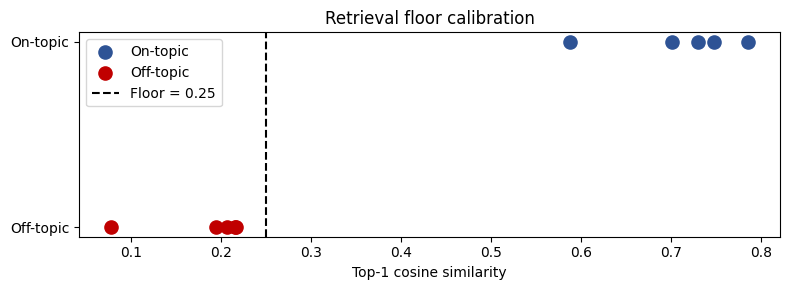

In [17]:
# Threshold calibration: separate on-topic from off-topic queries
ON_TOPIC = [
    "medication reconciliation at discharge",
    "discharge planning requirements",
    "patient education teach-back method",
    "follow-up appointment scheduling after discharge",
    "reducing preventable hospital readmissions",
]
OFF_TOPIC = [
    "what is the best pizza recipe",
    "how do I file my taxes",
    "python pandas groupby syntax",
    "who won the world series",
    "how to change a car tire",
]

on = [retrieve(q, k=1, min_sim=0.0)[0]["score"] for q in ON_TOPIC]
off = [retrieve(q, k=1, min_sim=0.0)[0]["score"] for q in OFF_TOPIC]

print(f"On-topic  similarity: min {min(on):.3f}  mean {np.mean(on):.3f}")
print(f"Off-topic similarity: max {max(off):.3f}  mean {np.mean(off):.3f}")
print(f"\nSeparation gap: {min(on) - max(off):+.3f}")
print(f"Current MIN_SIMILARITY = {MIN_SIMILARITY}")

if min(on) > max(off):
    lo, hi = max(off), min(on)
    print(f"Clean separation. Any floor in ({lo:.3f}, {hi:.3f}) works; "
          f"suggest {(lo + hi) / 2:.2f}")
else:
    print("Overlap between on- and off-topic scores - the floor alone cannot fully "
          "separate them. Keep the 'not covered' fallback and review flagged answers.")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(on, [1] * len(on), s=90, label="On-topic", color="#2E5395")
ax.scatter(off, [0] * len(off), s=90, label="Off-topic", color="#C00000")
ax.axvline(MIN_SIMILARITY, ls="--", c="k", label=f"Floor = {MIN_SIMILARITY}")
ax.set_yticks([0, 1]); ax.set_yticklabels(["Off-topic", "On-topic"])
ax.set_xlabel("Top-1 cosine similarity"); ax.legend(); ax.set_title("Retrieval floor calibration")
plt.tight_layout(); plt.show()

## 11. Evaluation — answer quality

Three checks, run without a human grader:

1. **Citation validity** — does every `[n]` point to a real retrieved excerpt? (catches hallucinated citations)
2. **Groundedness** — how much of the answer's vocabulary actually appears in the retrieved context? Crude but catches answers drifting into invented content.
3. **Refusal behavior** — does an off-topic question get declined rather than answered?

In [18]:
STOPWORDS = set("""the and for that with this from have been will should must patient
patients hospital care their they there which when what where about into than then them these those
your you are was were has had can may not but its it's also such more most other some""".split())

def groundedness(answer, hits):
    ctx = set(re.findall(r"\b[a-z]{5,}\b", " ".join(h["text"].lower() for h in hits))) - STOPWORDS
    ans = set(re.findall(r"\b[a-z]{5,}\b", answer.lower())) - STOPWORDS
    return len(ans & ctx) / len(ans) if ans else 0.0

QA_EVAL = [
    "What does AHRQ recommend for medication reconciliation at discharge?",
    "What are the required elements of hospital discharge planning?",
    "What follow-up is recommended after a patient is discharged home?",
    "What is the best way to cook a steak?",                      # off-topic control
    "What insulin dose should we give a patient with an A1C of 9?",  # out-of-scope clinical
]

results = []
for q in QA_EVAL:
    r = ask(q, verbose=False)
    if r["hits"]:
        results.append({
            "question": q[:52] + "...",
            "retrieved": len(r["hits"]),
            "grounded": round(groundedness(r["answer"], r["hits"]), 2),
            "citations": len(r["citations"]["cited"]),
            "invalid_cites": len(r["citations"]["invalid"]),
            "refused": False,
        })
    else:
        results.append({"question": q[:52] + "...", "retrieved": 0, "grounded": None,
                        "citations": 0, "invalid_cites": 0, "refused": True})

qa_df = pd.DataFrame(results)
display(qa_df)

ok = qa_df[~qa_df["refused"]]
print(f"Mean groundedness (answered): {ok['grounded'].mean():.2f}")
print(f"Answers with invalid citations: {int(qa_df['invalid_cites'].gt(0).sum())}")
print(f"Off-topic questions refused: {int(qa_df['refused'].sum())}")

,question,retrieved,grounded,citations,invalid_cites,refused
0,What does AHRQ recommend for medication reconc...,4,0.81,4,0,False
1,What are the required elements of hospital dis...,4,0.76,3,0,False
2,What follow-up is recommended after a patient ...,4,0.29,0,0,False
3,What is the best way to cook a steak?...,0,NaN,0,0,True
4,What insulin dose should we give a patient wit...,4,0.11,0,0,False


Mean groundedness (answered): 0.49
Answers with invalid citations: 0
Off-topic questions refused: 1


### Interpreting these numbers

- **Groundedness above ~0.5** means the answer is drawing its vocabulary from the retrieved excerpts. Below ~0.3 suggests the model is writing from its own knowledge — investigate.
- **Any invalid citation is a hard failure.** The number should be zero; if it isn't, tighten the prompt or reduce `k`.
- **The clinical question ("what insulin dose")** should either be refused or answered with process guidance only. If it returns a dose, the guardrail failed and the prompt needs strengthening.

## 12. Limitations & failure modes

### Known limitations
| Limitation | Consequence |
|---|---|
| Corpus is national CMS/AHRQ guidance | Says nothing about *this* hospital's formulary, staffing, or local protocol |
| Guidance is general, not diabetes-specific | Recommendations are transferable but not tailored to diabetes care |
| Retrieval is lexical-semantic, not clinical reasoning | Matches wording, not intent — an unusual phrasing may miss |
| No recency guarantee | If CMS updates a rule, the corpus is stale until documents are re-uploaded |
| Small corpus | Hit@k on a handful of gold questions is indicative, not statistically robust |

### Failure modes and mitigations
| Failure mode | Mitigation in this notebook |
|---|---|
| **Hallucinated guidance** — inventing a recommendation | Prompt restricts to excerpts; citations verified post-hoc (§8) |
| **Confident answer to an uncovered question** | Similarity floor + explicit "not covered" fallback (§6) |
| **Wrong-document retrieval** | Per-source cap, Hit@k evaluation (§10) |
| **Chunk boundary splits a recommendation** | Paragraph-aware chunking + 150-char overlap (§4) |
| **Scope creep into clinical advice** | Prompt rule 5 forbids drug/dose recommendations; tested in §11 |
| **Over-trust by staff** | Every answer displays its sources; briefs are advisory, clinician decides |
| **Stale guidance** | Corpus lives in Drive; re-run §3–6 after updating documents |

### What this component does *not* do
It does not decide who gets an intervention (the model ranks; a human decides), does not make
clinical treatment recommendations, and does not replace a pharmacist's judgment. It reduces the
time between *"this patient is flagged"* and *"here is the relevant guidance, with the source."*

## 13. Export retrieval artifacts

In [19]:
OUT_DIR = "/content/drive/MyDrive/TransitionRx_Corpus/_index"
os.makedirs(OUT_DIR, exist_ok=True)

faiss.write_index(index, f"{OUT_DIR}/transitionrx_faiss.index")
chunk_df.to_parquet(f"{OUT_DIR}/transitionrx_chunks.parquet", index=False)

rag_meta = {
    "embedding_model": EMBED_MODEL,
    "generation_model": GEN_MODEL,
    "n_documents": len(paths),
    "n_chunks": len(CHUNKS),
    "chunk_size": CHUNK_SIZE,
    "chunk_overlap": CHUNK_OVERLAP,
    "min_similarity": MIN_SIMILARITY,
    "max_per_source": MAX_PER_SOURCE,
    "sources": sorted({c["source"] for c in CHUNKS}),
    "retrieval_hit_at_3": float(eval_df["hit@3"].mean()),
    "mean_groundedness": float(ok["grounded"].mean()),
}
with open(f"{OUT_DIR}/transitionrx_rag_metadata.json", "w") as f:
    json.dump(rag_meta, f, indent=2)

print("Saved to", OUT_DIR)
for k, v in rag_meta.items():
    if k != "sources":
        print(f"  {k}: {v}")

Saved to /content/drive/MyDrive/TransitionRx_Corpus/_index
  embedding_model: sentence-transformers/all-MiniLM-L6-v2
  generation_model: gpt-4o
  n_documents: 6
  n_chunks: 1408
  chunk_size: 900
  chunk_overlap: 150
  min_similarity: 0.25
  max_per_source: 2
  retrieval_hit_at_3: 0.6
  mean_groundedness: 0.49250000000000005


## Summary

| Element | Implementation |
|---|---|
| Document collection | Curated CMS/AHRQ discharge-planning corpus in Drive (§2) |
| Loading & preprocessing | PDF/DOCX/TXT readers + de-hyphenation, unwrapping, page-number stripping (§3) |
| Chunking | Paragraph-aware, 900 chars, 150 overlap, source+page metadata (§4) |
| Embeddings | `all-MiniLM-L6-v2`, 384-dim, normalized, local (§5) |
| Retrieval | FAISS exact inner-product + similarity floor + per-source cap (§6) |
| Prompt design | Excerpt-only, cite-or-decline, no clinical orders (§7) |
| Generated response | Claude via API, citation-verified (§8) |
| Source grounding | Inline `[n]` citations, post-hoc validation, sources always displayed (§8–9) |
| Evaluation | Hit@k, floor calibration, groundedness, refusal testing (§10–11) |
| Limitations & failure modes | Documented with mitigations (§12) |

**Why this isn't a generic chatbot:** the corpus is scoped to one decision, off-topic questions
are refused by design, and the primary function (§9) takes a flagged patient's model drivers as
input — it cannot operate without the analytics it supports.